# Exercise 08

## Changes to the Evacuation Model

To enable exercises about stochasticity, the evacuation model has been modified:

* Isolated stochastic processes
  * *rng_propagate* for information propagation
  * *rng_placement* for placing agents in the room
  * *rng_orientation* for the agents' initial orientation

## Evaluation Code


In [25]:
from mesa.batchrunner import batch_run
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import sys
sys.path.insert(0,'../../abmodel')
from IPython.utils import io

from fire_evacuation.model import FireEvacuation
from fire_evacuation.agent import Human


unikcolors = [np.array((80,149,200))/255, np.array((74,172,150))/255,
                                                  np.array((234,195,114))/255, np.array((199,16,92))/255]
uniks = LinearSegmentedColormap.from_list( 'unik', unikcolors)

def plot_results(datas, descriptions, ylabel):
    plt.figure(0)
    fig, ax = plt.subplots()
    ax.set_ylabel(ylabel)
    for i in range(0, len(descriptions)):
        datas[i]['nervousness_mean'] = datas[i]['nervousness_mean'] + i*0.025
        plt.scatter(datas[i]['nervousness_mean'], datas[i]['Step'], label=descriptions[i])
    ax.legend(loc="upper right")
    ax.xlabel("Nervousness mean")
    fig.set_size_inches(12,8)
    plt.grid(True)

# Task 02 (Stochasticity in the evacuation model)

## Subtask 02 (Isolation of random processes)

**Points: 20**

There are many random processes involved in the evacuation model. To get an idea about their particular impact on the model, underlying random number streams can be isolated, i.e. for each process as separate random number stream can be used.

Execute the following code and discuss the results. Can you formulate statements about the impact of each of the random processes?

<Figure size 432x288 with 0 Axes>

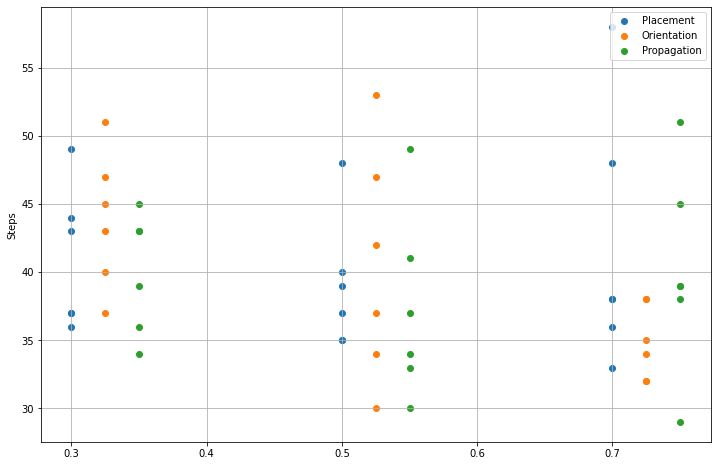

In [24]:
with io.capture_output() as captured:
    params = dict(
        nervousness_mean = {0.3, 0.5,0.7},
        alarm_believers_prop=0.9,
        interact_moore = 0.2,
        seed = 0,
        seed_placement = range(0,6),
        seed_orientation = 0,
        seed_propagate = 0
    )
    results_placement = batch_run(
            FireEvacuation,
            parameters=params,
            iterations = 1,
            max_steps = 500,
        )
    
    params = dict(
        nervousness_mean = {0.3, 0.5,0.7},
        alarm_believers_prop=0.9,
        interact_moore = 0.2,
        seed = 0,
        seed_placement = 0,
        seed_orientation = range(0,6),
        seed_propagate = 0
    )
    results_orientation = batch_run(
            FireEvacuation,
            parameters=params,
            iterations = 1,
            max_steps = 500,
        )
    
    params = dict(
        nervousness_mean = {0.3, 0.5,0.7},
        alarm_believers_prop=0.9,
        interact_moore = 0.2,
        seed = 0,
        seed_placement = 0,
        seed_orientation = 0,
        seed_propagate = range(0,6)
    )    
    results_propagate = batch_run(
            FireEvacuation,
            parameters=params,
            iterations = 1,
            max_steps = 500,
        )
    
data_placement = pd.DataFrame(results_placement)[['nervousness_mean', 'Step']].round(decimals=2)
data_orientation = pd.DataFrame(results_orientation)[['nervousness_mean', 'Step']].round(decimals=2)
data_propagate = pd.DataFrame(results_propagate)[['nervousness_mean', 'Step']].round(decimals=2)

datas = list([data_placement, data_orientation, data_propagate])
plot_results(datas, ["Placement", "Orientation", "Propagation"], ylabel="Steps")

**Describe your findings here (max. 300 words)**

## Subtask 03 (Contingency)

**Points: 20**

Contingency means the dependence of random processes on the context. Find two stochastic processes in the evacuation model that can be modelled with contingency. Provide pseudo code for each of the processes that introduces contingency. Argue for your approach!


**Write your answer here (300 words max. and pseudo code)!**

## Subtask 04 (Random to deterministic)

**Points: 20**

If one wants to avoid random numbers in the evacuation model, how could the propagation of information (alarm situation) be modeled in more detail without random processes? Provide pseudo code! What are the advantages and disadvantages of such an approach?

Are there other processes that could be modeled deterministic and detailed instead of randomly?

**Write your anwser here (300 words max. and pseudo code)**